Install required libraries

In [35]:
!pip install pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import Libraries

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


Part A - Data Preparation

In [37]:
#Data Frame
df = pd.read_csv("Data/Dataset.csv")

#Target Variables
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
my_target_names = ['No', 'Yes']
feature_columns = ['Monthly Charges', 'Contract Length (Months)', 'Internet Usage (GB)', 'Support Tickets']

#Separate features and target variable
x = df[feature_columns]
y = df['Churn']

Part B - Expoloratory Data Analysis

In [38]:
print("Dataset Information")
df.info()

print("\n Missing Values")
print(df.isnull().sum())

print("\n Summary Statistics")
print(df.describe())

highest_charge = df['Monthly Charges'].max()
avg_usage = df['Internet Usage (GB)'].mean()

print(f"\n Highest Total Charges: {highest_charge}")
print(f" Average Internet Usage: {avg_usage:.2f} GB")

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Customer ID               10 non-null     str  
 1   Monthly Charges           10 non-null     int64
 2   Contract Length (Months)  10 non-null     int64
 3   Internet Usage (GB)       10 non-null     int64
 4   Support Tickets           10 non-null     int64
 5   Churn                     10 non-null     int64
dtypes: int64(5), str(1)
memory usage: 612.0 bytes

 Missing Values
Customer ID                 0
Monthly Charges             0
Contract Length (Months)    0
Internet Usage (GB)         0
Support Tickets             0
Churn                       0
dtype: int64

 Summary Statistics
       Monthly Charges  Contract Length (Months)  Internet Usage (GB)  \
count        10.000000                 10.000000             10.00000   
mean        104.000000                

Part C - Data Splitting

In [39]:

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3, 
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))


Training Data: 7
Testing Data: 3


Part D - Decision Tree Model Development

In [40]:
#Create Decision Tree Classifier
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

print(model)

DecisionTreeClassifier(max_depth=3, random_state=42)


In [41]:
#Model Training
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


Part E - Prediction and Evaluation

In [42]:
#Predict test Data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 1]


In [43]:
#Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", accuracy)

Accuracy:  1.0


In [44]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 0]
 [0 1]]


In [45]:
#Classification Report

report = classification_report(
    y_test,
    y_pred,
    target_names=my_target_names
)

print(report)

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         2
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



Part F - Data Visualization

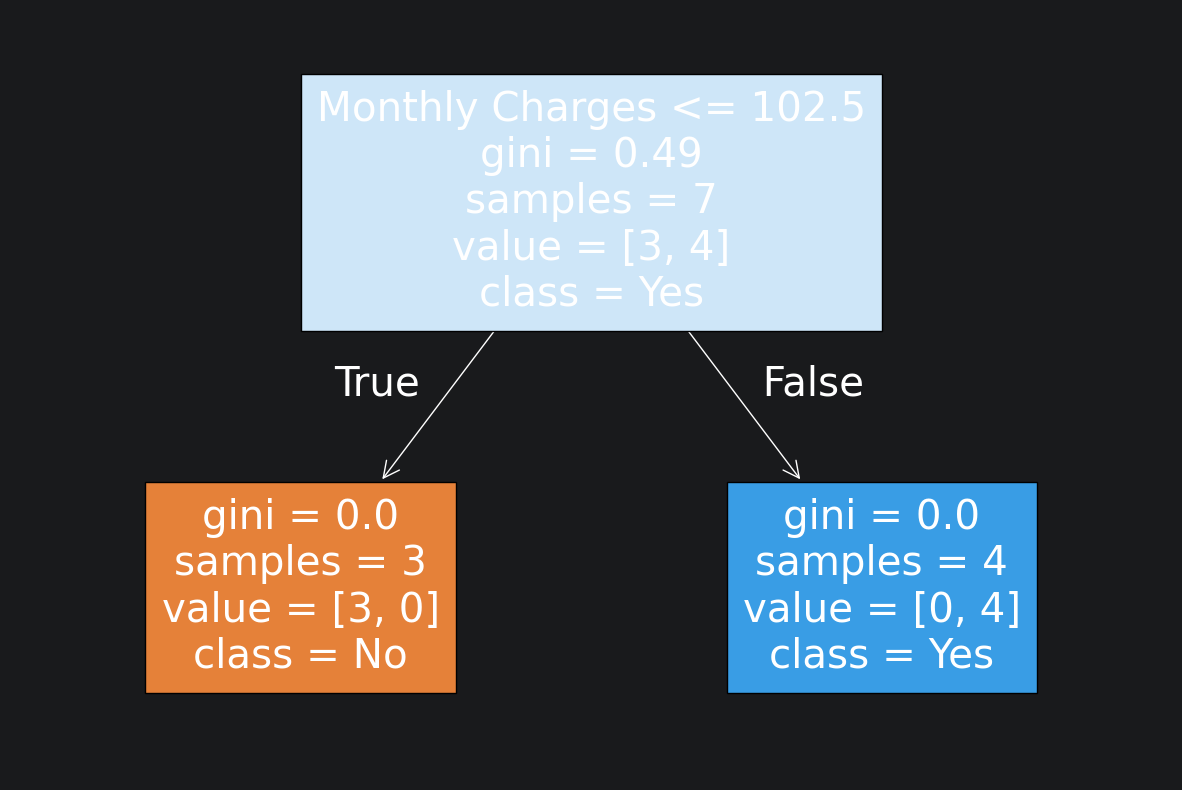

In [46]:
# Visualize the Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(
    model,
    feature_names=feature_columns,
    class_names=my_target_names,
    filled=True
)
plt.show()


Analysis

Root Node

Leaf Nodes 

Decision Rules

Leaf Nodes

Part G - Feature Importance Analysis

In [47]:
importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)



,Feature,Importance
0,Monthly Charges,1.0
1,Contract Length (Months),0.0
2,Internet Usage (GB),0.0
3,Support Tickets,0.0


Part H - Overfitting Experiment

In [48]:
#create another decision tree with no max_depth
overfit_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_model.fit(X_train, y_train)

overfit_pred = overfit_model.predict(X_test)

print("Overfitted Model Accuracy:")
print(accuracy_score(y_test, overfit_pred))

Overfitted Model Accuracy:
1.0


In [49]:
#Compare Two Trees
print("Controlled Tree Depth Accuracy:", accuracy)
print("Overfitted Tree Accuracy:", accuracy_score(y_test, overfit_pred))




Controlled Tree Depth Accuracy: 1.0
Overfitted Tree Accuracy: 1.0


### Analyze Generalization Performance

Lorem ipsum

Guide Questions:

1. Which feature most influences churn prediction?
2. Why are support tickets important?
3. How does max_depth affect complexity?
4. What signs indicate overfitting?
5. Why are Decision Trees interpretable?
6. How can predictive analytics improve retention?
